# SVM Exercises

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [12]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

# YOUR CODE HERE
data = pd.read_csv(url, names=names)

invalid = ['plas', 'pres', 'skin', 'test', 'mass']
for i in invalid:
    data[i] = data[i].replace(to_replace=0, value=np.nan)
data = data.dropna(axis=0).reset_index(drop=True)
data.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


Split data into training, colidation, and test sets with a test size of 25%

In [16]:
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

test_size = 0.25
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size=test_size, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [27]:
# YOUR CODE HERE
svm_high = SVC(gamma=1, C=1)
svm_high.fit(X_train, y_train)

SVC(C=1, gamma=1)

Print accuracy of training and validation data

In [28]:
# YOUR CODE HERE
y_train_pred=svm_high.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=svm_high.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  100.0
Validation Accuracy is  67.56756756756756


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [29]:
# YOUR CODE HERE
svm_low = SVC(gamma=0.001, C=1)
svm_low.fit(X_train, y_train)

SVC(C=1, gamma=0.001)

Print accuracy of training and validation data

In [30]:
# YOUR CODE HERE
y_train_pred=svm_low.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=svm_low.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  87.27272727272727
Validation Accuracy is  74.32432432432432


Explain the accuracy results below.

(YOUR ANSWER HERE)
High Gamma
Training Accuracy is  100.0
Validation Accuracy is  67.56756756756756
Low gamma
Training Accuracy is  87.27272727272727
Validation Accuracy is  74.32432432432432

High gamma has perfect trainng accuracy but low validation accuracy while training  accuracy in low gamma is lower but has higher validation accuracy





Print the confusion matrices for your high and low gamma models (both numeric and visualized)

High Gamma Confusion Matrix:
[[50  0]
 [24  0]]
Low Gamma Confusion Matrix:
[[48  2]
 [17  7]]


/tmp/ipykernel_1646/2554345918.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, fontsize=16)
/tmp/ipykernel_1646/2554345918.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels, fontsize=16)


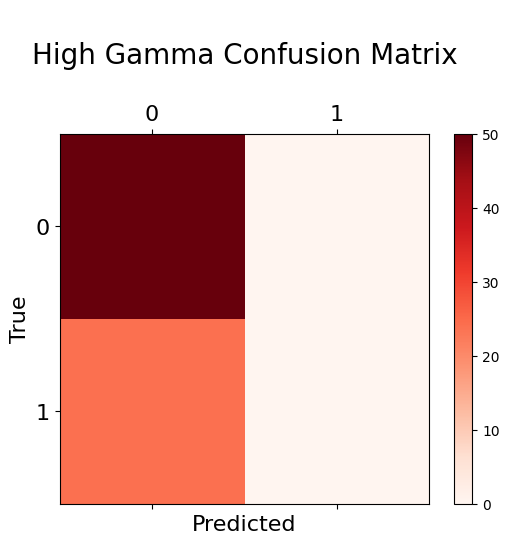

/tmp/ipykernel_1646/2554345918.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, fontsize=16)
/tmp/ipykernel_1646/2554345918.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels, fontsize=16)


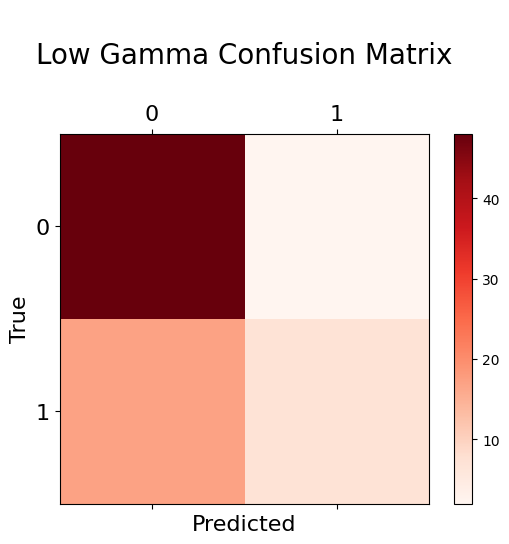

In [31]:
# YOUR CODE HERE
def plot_cmatrix(cm,labels,title='Confusion Matrix'):
  fig = plt.figure()
  ax = fig.add_subplot(111)
  cax = ax.matshow(cm,cmap='Reds')
  plt.title('\n'+title+'\n', fontsize=20)
  fig.colorbar(cax)
  ax.set_xticklabels([''] + labels, fontsize=16)
  ax.set_yticklabels([''] + labels, fontsize=16)
  plt.xlabel('Predicted', fontsize=16)
  plt.ylabel('True', fontsize=16)
  plt.show()

labels = [0,1]
cm_high = metrics.confusion_matrix(y_val, svm_high.predict(X_val), labels=labels)
cm_low = metrics.confusion_matrix(y_val, svm_low.predict(X_val), labels=labels)

print("High Gamma Confusion Matrix:")
print(cm_high)
print("Low Gamma Confusion Matrix:")
print(cm_low)

plot_cmatrix(cm_high, labels, title='High Gamma Confusion Matrix')
plot_cmatrix(cm_low, labels, title='Low Gamma Confusion Matrix')